In [1]:
import pandas as pd
from category_encoders import TargetEncoder as te

In [2]:
### Loading Cleaned Datasets
train_df = pd.read_csv('Cleaned_Train.csv')
test_df = pd.read_csv('Cleaned_Test.csv')
holdout_df = pd.read_csv('HoldOut Set.csv')

In [3]:
train_df["date"] = pd.to_datetime(train_df["date"])
test_df["date"] = pd.to_datetime(test_df["date"])
holdout_df["date"] = pd.to_datetime(holdout_df["date"])

In [4]:
train_df.head()

,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,...,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,lat,lng
0,2012-03-31,46550.0,217450.0,31.813674,110.183666,14.0,23.0,44.0,64.0,59.5,...,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,Atlanta-Sandy Springs-Alpharetta,33.7338,-84.3922
1,2012-03-31,340000.0,349900.0,171.817343,242.367722,13.0,18.0,30.0,54.0,126.0,...,419600.0,3207.0,147.0,5982.0,5982.0,2794.0,352711.838012,Boston-Cambridge-Newton,42.5584,-71.1007
2,2012-03-31,259750.0,284950.0,141.977239,166.023273,14.0,26.0,32.0,47.0,107.0,...,337800.0,4928.0,305.0,7923.0,7923.0,4319.0,281869.800260,Boston-Cambridge-Newton,42.5584,-71.1007
3,2012-03-31,364000.0,349900.0,134.366391,181.914518,5.0,9.0,19.0,35.0,217.0,...,440300.0,2947.0,131.0,4994.0,4994.0,2593.0,324802.060960,Boston-Cambridge-Newton,42.5584,-71.1007
4,2012-03-31,270000.0,344900.0,137.327354,141.493195,12.0,12.0,24.0,35.0,145.0,...,327400.0,3013.0,99.0,4775.0,4775.0,2722.0,267980.936958,Boston-Cambridge-Newton,42.5584,-71.1007


In [5]:
def get_date_features (df):
    df["year"] = df["date"].dt.year
    df["quarter"] = df["date"].dt.quarter
    df["month"] = df["date"].dt.month

    # Reorder columns
    df.insert(1, "year", df.pop("year"))
    df.insert(2, "quarter", df.pop("quarter"))
    df.insert(3, "month", df.pop("month"))
    return df

In [6]:
train_df = get_date_features(train_df)
test_df = get_date_features(test_df)
holdout_df = get_date_features(holdout_df)

In [7]:
print (train_df.shape)
print (test_df.shape)
print (holdout_df.shape)

(490092, 43)
(125750, 43)
(149424, 41)


In [8]:
train_df.head()

,date,year,quarter,month,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,...,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,lat,lng
0,2012-03-31,2012,1,3,46550.0,217450.0,31.813674,110.183666,14.0,23.0,...,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,Atlanta-Sandy Springs-Alpharetta,33.7338,-84.3922
1,2012-03-31,2012,1,3,340000.0,349900.0,171.817343,242.367722,13.0,18.0,...,419600.0,3207.0,147.0,5982.0,5982.0,2794.0,352711.838012,Boston-Cambridge-Newton,42.5584,-71.1007
2,2012-03-31,2012,1,3,259750.0,284950.0,141.977239,166.023273,14.0,26.0,...,337800.0,4928.0,305.0,7923.0,7923.0,4319.0,281869.800260,Boston-Cambridge-Newton,42.5584,-71.1007
3,2012-03-31,2012,1,3,364000.0,349900.0,134.366391,181.914518,5.0,9.0,...,440300.0,2947.0,131.0,4994.0,4994.0,2593.0,324802.060960,Boston-Cambridge-Newton,42.5584,-71.1007
4,2012-03-31,2012,1,3,270000.0,344900.0,137.327354,141.493195,12.0,12.0,...,327400.0,3013.0,99.0,4775.0,4775.0,2722.0,267980.936958,Boston-Cambridge-Newton,42.5584,-71.1007


In [9]:
zip_counts = train_df["zipcode"].value_counts()

train_df["zipcode_freq"] = train_df["zipcode"].map(zip_counts)
test_df["zipcode_freq"] = test_df["zipcode"].map(zip_counts).fillna(0)
holdout_df["zipcode_freq"] = holdout_df["zipcode"].map(zip_counts).fillna(0)

print("Zip freq example (train):")
print(train_df[["zipcode", "zipcode_freq"]].head())


Zip freq example (train):
   zipcode  zipcode_freq
0    30002            94
1     2739            94
2     2762            94
3     2770            94
4     3032            94


In [10]:
te = te(cols=["city_full"], smoothing = 10.0)

train_df["city_encoded"] = te.fit_transform(train_df["city_full"], train_df["price"])
test_df["city_encoded"] = te.transform(test_df["city_full"])
holdout_df["city_encoded"] = te.transform(holdout_df["city_full"])

print("City encoding example (train):")
print(train_df[["city_full", "city_encoded"]].head())


City encoding example (train):
                          city_full   city_encoded
0  Atlanta-Sandy Springs-Alpharetta  192627.058387
1           Boston-Cambridge-Newton  472075.429542
2           Boston-Cambridge-Newton  472075.429542
3           Boston-Cambridge-Newton  472075.429542
4           Boston-Cambridge-Newton  472075.429542


<Axes: >

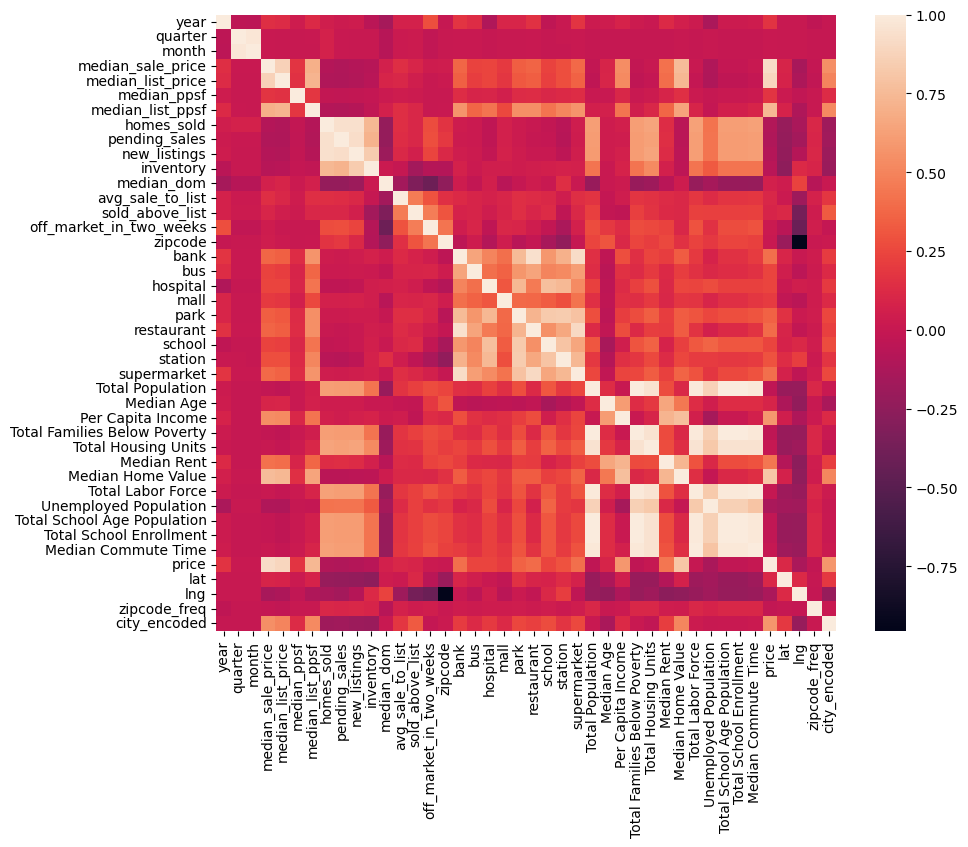

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (10,8))
dt = train_df.corr(numeric_only = True)
sns.heatmap(data = dt)

In [12]:
# Drop leakage column "median_sale_price"
drop_cols = ["date", "city_full", "city", "zipcode", "median_sale_price"]
train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)
holdout_df.drop(columns=drop_cols, inplace=True)

In [13]:
train_df.to_csv('Final_Train.csv', index = False)
test_df.to_csv('Final_Test.csv', index = False)
holdout_df.to_csv('Final_Holdout.csv', index = False)

In [14]:
train_df.isnull().sum()

year                            0
quarter                         0
month                           0
median_list_price               0
median_ppsf                     0
median_list_ppsf                0
homes_sold                      0
pending_sales                   0
new_listings                    0
inventory                       0
median_dom                      0
avg_sale_to_list                0
sold_above_list                 0
off_market_in_two_weeks         0
bank                            0
bus                             0
hospital                        0
mall                            0
park                            0
restaurant                      0
school                          0
station                         0
supermarket                     0
Total Population                0
Median Age                      0
Per Capita Income               0
Total Families Below Poverty    0
Total Housing Units             0
Median Rent                     0
Median Home Va